# Heart Disease UCI Project Part 2: In-depth Data Exploration and Preparation

Student ID: Mormoo5363  
Date: 05-24-2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from IPython.display import display, Markdown

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "Mormoo5363"

data = pd.read_csv("heart_disease_uci.csv")

display(Markdown("## Load and Explore Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

display(data.head())
print("Dataset shape:", data.shape)
print("\nDataset Info:")
print(data.info())

display(data.describe())

## Load and Explore Dataset

Date: 2026-05-24

Student ID: Mormoo5363

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Dataset shape: (920, 16)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [3]:
import pandas as pd
from IPython.display import display, Markdown

display(Markdown("## Missing Values Summary"))

missing_values = data.isnull().sum().sort_values(ascending=False)

print(missing_values)

## Missing Values Summary

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
id            0
age           0
sex           0
dataset       0
cp            0
num           0
dtype: int64


In [4]:
display(Markdown("## Univariate Analysis: Summary Statistics"))

numerical_features = [
    "age", "trestbps", "chol", "thalch", "oldpeak", "ca", "num"
]

display(data[numerical_features].describe())

## Univariate Analysis: Summary Statistics

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## Box Plots for Outlier Detection

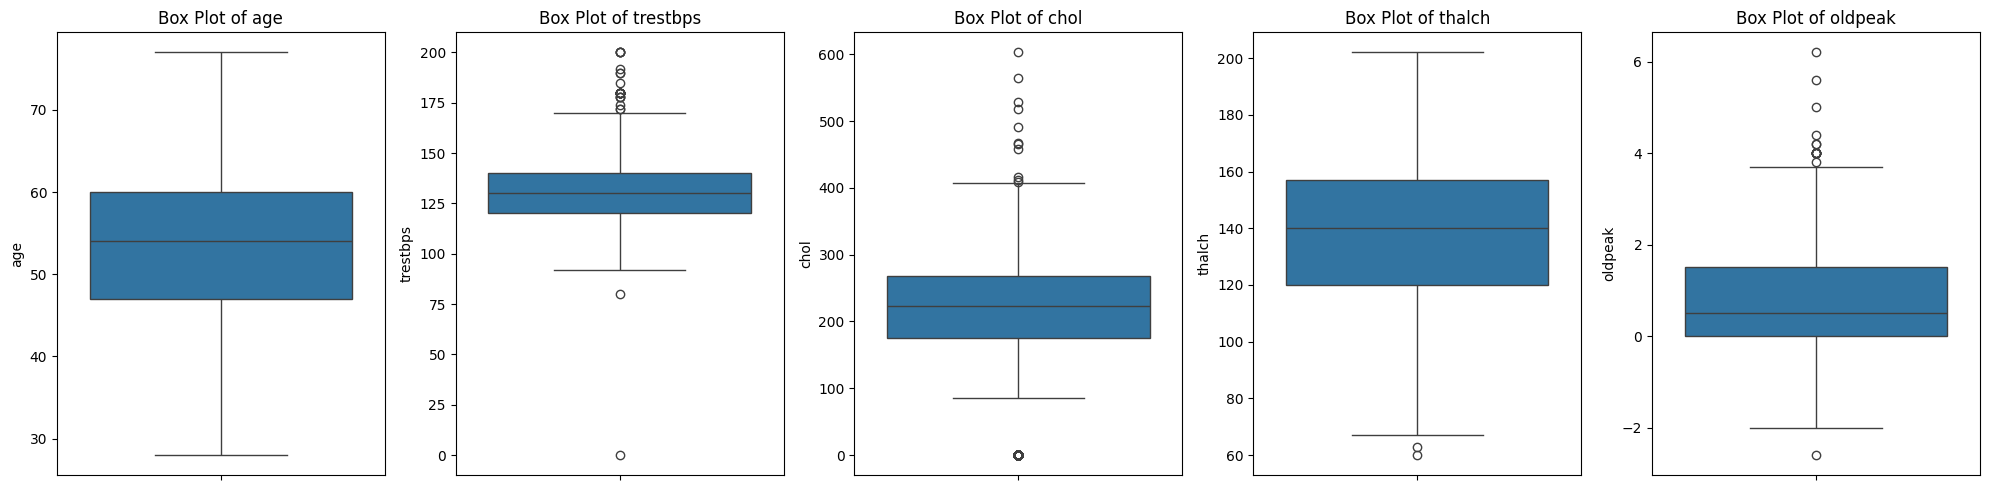

In [5]:
display(Markdown("## Box Plots for Outlier Detection"))

box_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]

fig, axes = plt.subplots(1, len(box_features), figsize=(20, 5))

for i, feature in enumerate(box_features):
    sns.boxplot(y=data[feature], ax=axes[i])
    axes[i].set_title(f"Box Plot of {feature}")

plt.tight_layout()
plt.show()

In [6]:
display(Markdown("## Correlation Matrix"))

corr_matrix = data[numerical_features].corr()

display(corr_matrix)

## Correlation Matrix

,age,trestbps,chol,thalch,oldpeak,ca,num
age,1.000000,0.244253,-0.086234,-0.365778,0.258243,0.370416,0.339596
trestbps,0.244253,1.000000,0.092853,-0.104899,0.161908,0.093705,0.122291
chol,-0.086234,0.092853,1.000000,0.236121,0.047734,0.051606,-0.231547
thalch,-0.365778,-0.104899,0.236121,1.000000,-0.151174,-0.264094,-0.366265
oldpeak,0.258243,0.161908,0.047734,-0.151174,1.000000,0.281817,0.443084
ca,0.370416,0.093705,0.051606,-0.264094,0.281817,1.000000,0.516216
num,0.339596,0.122291,-0.231547,-0.366265,0.443084,0.516216,1.000000


## Heatmap of Numerical Feature Correlations

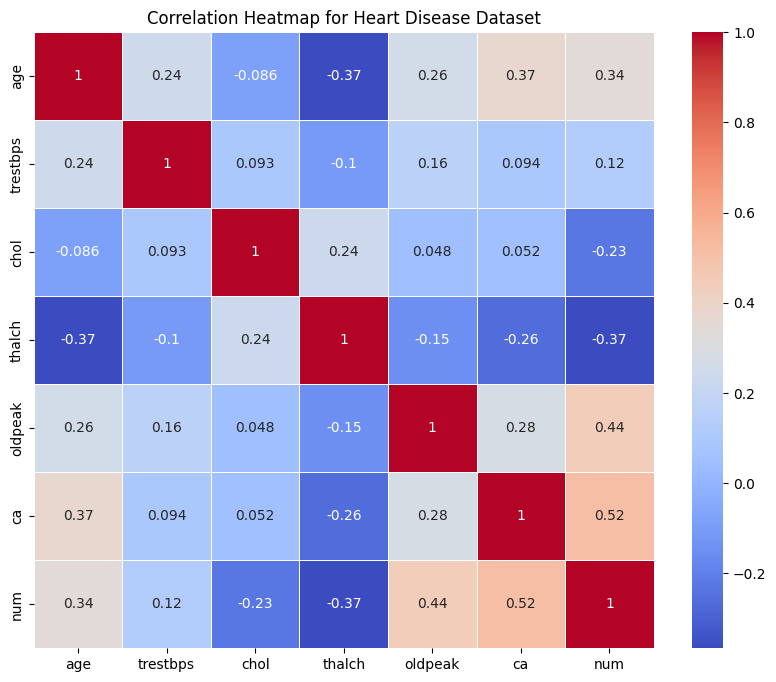

In [7]:
display(Markdown("## Heatmap of Numerical Feature Correlations"))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap for Heart Disease Dataset")
plt.show()

## Pair Plot for Patient Risk Stratification

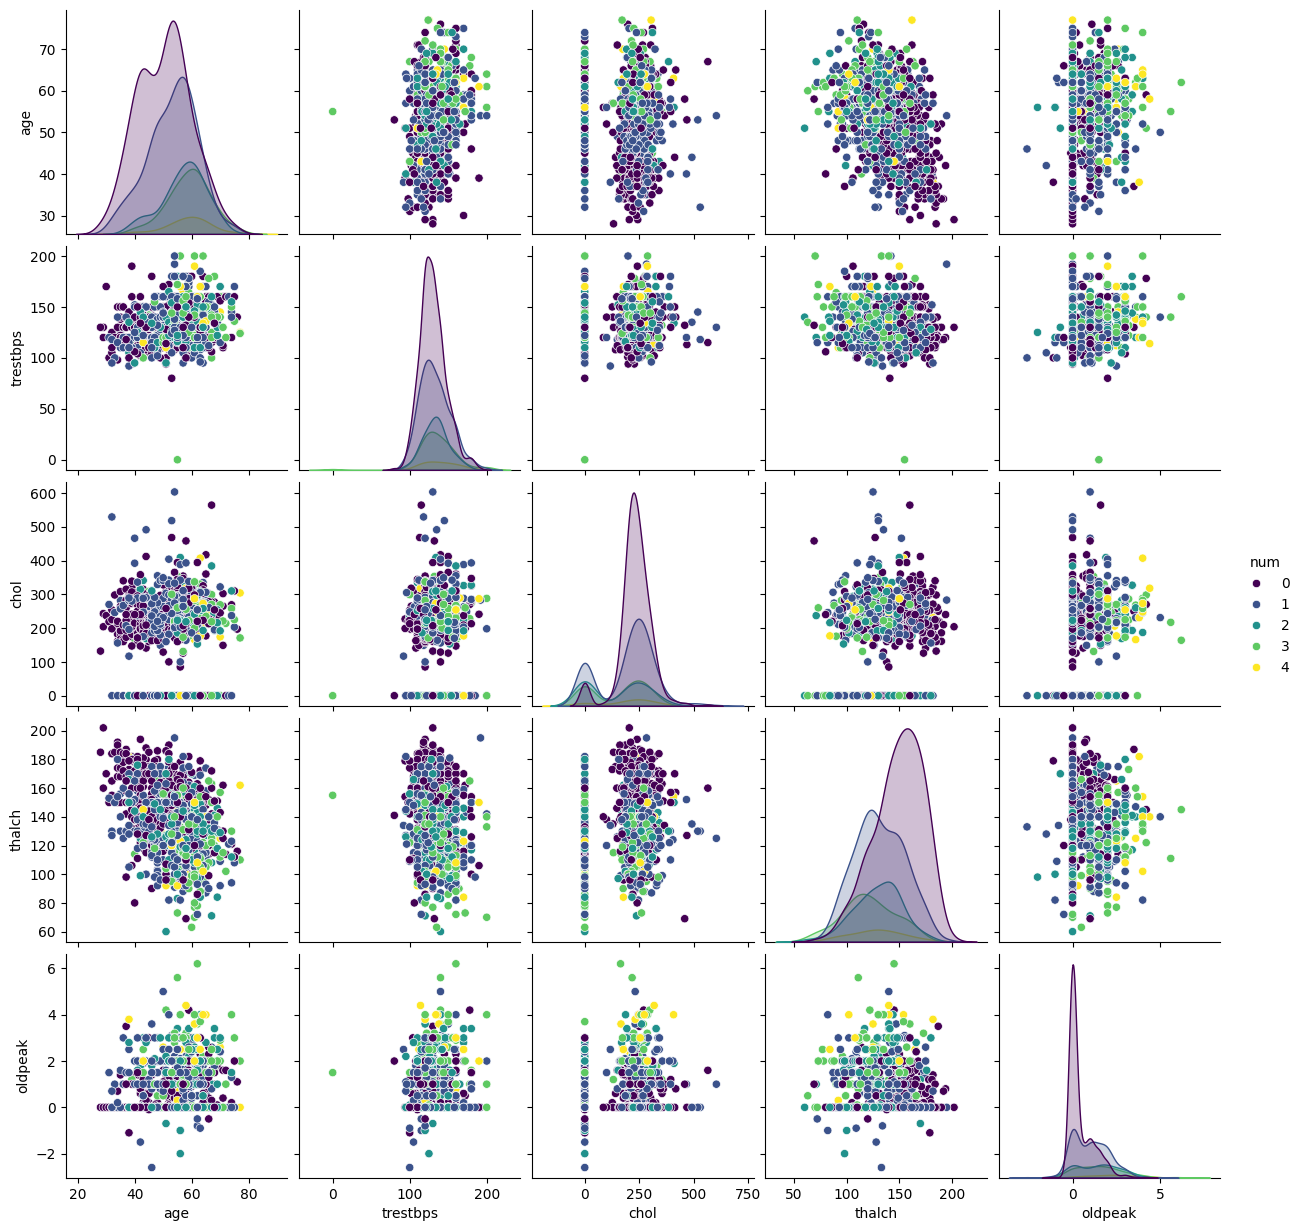

In [8]:
display(Markdown("## Pair Plot for Patient Risk Stratification"))

cluster_features = ["age", "trestbps", "chol", "thalch", "oldpeak", "num"]

sns.pairplot(
    data[cluster_features].dropna(),
    hue="num",
    palette="viridis"
)

plt.show()

## Bivariate Analysis: Heart Disease by Sex

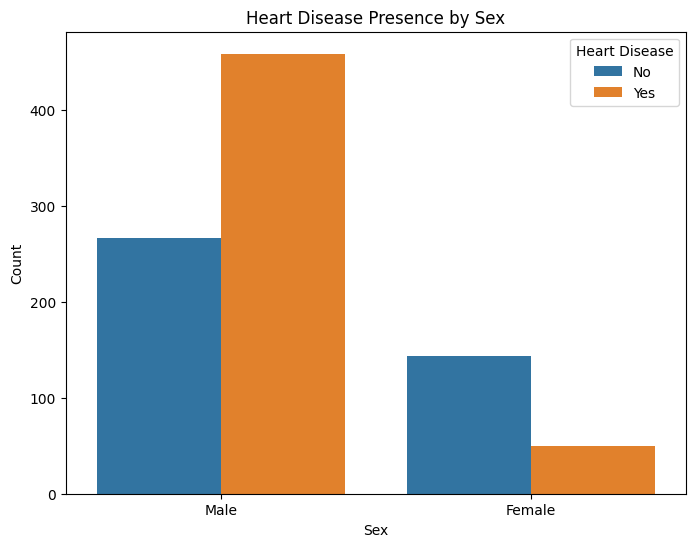

In [9]:
display(Markdown("## Bivariate Analysis: Heart Disease by Sex"))

heart_disease_binary = data.copy()
heart_disease_binary["heart_disease"] = heart_disease_binary["num"].apply(
    lambda x: 1 if x > 0 else 0
)

plt.figure(figsize=(8, 6))

sns.countplot(
    x="sex",
    hue="heart_disease",
    data=heart_disease_binary
)

plt.title("Heart Disease Presence by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Heart Disease", labels=["No", "Yes"])

plt.show()

## Bivariate Analysis: Chest Pain Type and Heart Disease

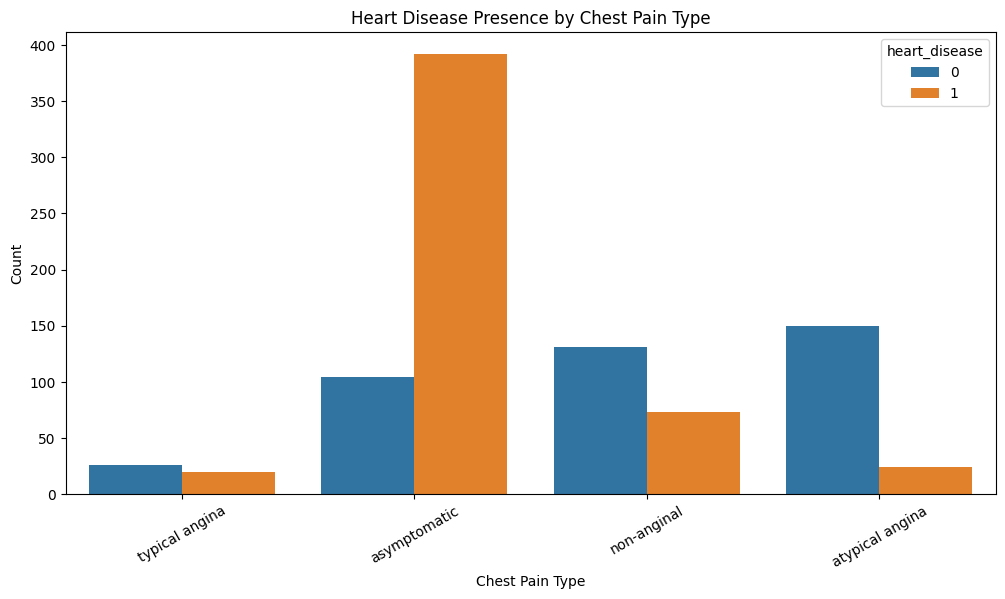

In [10]:
display(Markdown("## Bivariate Analysis: Chest Pain Type and Heart Disease"))

plt.figure(figsize=(12, 6))

sns.countplot(
    x="cp",
    hue="heart_disease",
    data=heart_disease_binary
)

plt.title("Heart Disease Presence by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.show()

In [11]:
display(Markdown("## Data Preprocessing"))

processed_data = data.copy()

# Drop ID because it is only an identifier
processed_data = processed_data.drop(columns=["id"])

# Fill missing numeric values with median
numeric_columns = processed_data.select_dtypes(include=["int64", "float64"]).columns

for column in numeric_columns:
    processed_data[column] = processed_data[column].fillna(
        processed_data[column].median()
    )

# Fill missing categorical values with mode
categorical_columns = processed_data.select_dtypes(include=["object", "bool"]).columns

for column in categorical_columns:
    processed_data[column] = processed_data[column].fillna(
        processed_data[column].mode()[0]
    )

print("Missing values after cleaning:")
print(processed_data.isnull().sum())

## Data Preprocessing

Missing values after cleaning:
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


C:\Users\Morgan Moore\AppData\Local\Temp\ipykernel_8748\1184420771.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = processed_data.select_dtypes(include=["object", "bool"]).columns


In [12]:
display(Markdown("## Feature Engineering"))

# Create binary heart disease label for classification
processed_data["heart_disease"] = processed_data["num"].apply(
    lambda x: 1 if x > 0 else 0
)

# Create cholesterol risk bins for analysis
processed_data["cholesterol_group"] = pd.cut(
    processed_data["chol"],
    bins=[0, 200, 240, 700],
    labels=["Normal", "Borderline High", "High"]
)

# Create age group bins
processed_data["age_group"] = pd.cut(
    processed_data["age"],
    bins=[0, 40, 55, 70, 100],
    labels=["Young Adult", "Middle Age", "Older Adult", "Senior"]
)

display(processed_data[["age", "age_group", "chol", "cholesterol_group", "num", "heart_disease"]].head())

## Feature Engineering

,age,age_group,chol,cholesterol_group,num,heart_disease
0,63,Older Adult,233.0,Borderline High,0,0
1,67,Older Adult,286.0,High,2,1
2,67,Older Adult,229.0,Borderline High,1,1
3,37,Young Adult,250.0,High,0,0
4,41,Middle Age,204.0,Borderline High,0,0


In [13]:
display(Markdown("## One-Hot Encoding Categorical Features"))

encoded_data = pd.get_dummies(
    processed_data,
    columns=[
        "sex",
        "dataset",
        "cp",
        "fbs",
        "restecg",
        "exang",
        "slope",
        "thal",
        "cholesterol_group",
        "age_group"
    ],
    drop_first=True
)

display(encoded_data.head())
print("Encoded dataset shape:", encoded_data.shape)

## One-Hot Encoding Categorical Features

,age,trestbps,chol,thalch,oldpeak,ca,num,heart_disease,sex_Male,dataset_Hungary,...,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,cholesterol_group_Borderline High,cholesterol_group_High,age_group_Middle Age,age_group_Older Adult,age_group_Senior
0,63,145.0,233.0,150.0,2.3,0.0,0,0,True,False,...,False,False,False,False,False,True,False,False,True,False
1,67,160.0,286.0,108.0,1.5,3.0,2,1,True,False,...,True,True,False,True,False,False,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,1,1,True,False,...,True,True,False,False,True,True,False,False,True,False
3,37,130.0,250.0,187.0,3.5,0.0,0,0,True,False,...,False,False,False,True,False,False,True,False,False,False
4,41,130.0,204.0,172.0,1.4,0.0,0,0,False,False,...,False,False,True,True,False,True,False,True,False,False


Encoded dataset shape: (920, 28)


In [14]:
from sklearn.preprocessing import StandardScaler

display(Markdown("## Scaling Numerical Features"))

scaler = StandardScaler()

scale_columns = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

encoded_data[scale_columns] = scaler.fit_transform(encoded_data[scale_columns])

display(encoded_data[scale_columns].head())

## Scaling Numerical Features

,age,trestbps,chol,thalch,oldpeak,ca
0,1.007386,0.705176,0.303643,0.489727,1.368109,-0.361400
1,1.432034,1.518569,0.789967,-1.181478,0.611589,4.411152
2,1.432034,-0.650479,0.266939,-0.345875,1.651804,2.820301
3,-1.752828,-0.108217,0.459634,1.961979,2.502889,-0.361400
4,-1.328180,-0.108217,0.037541,1.365120,0.517024,-0.361400


## PCA for Dimensionality Reduction

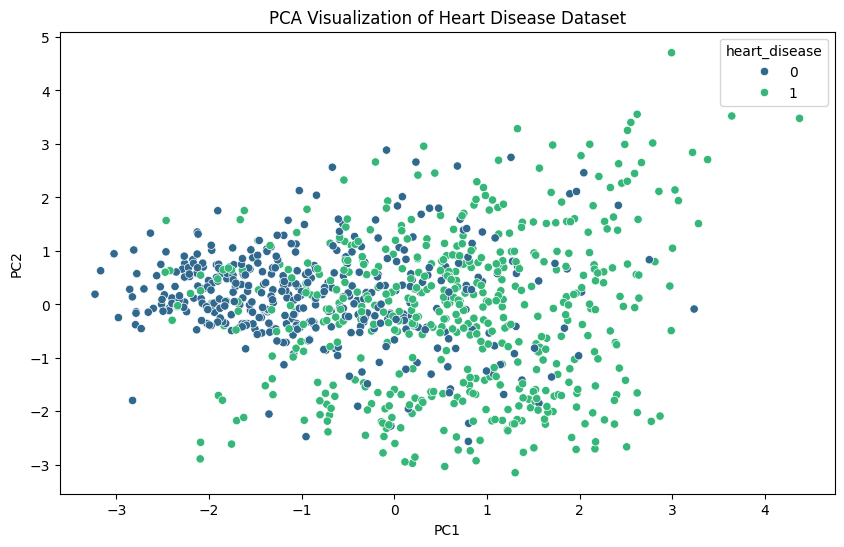

Explained variance ratio: [0.21168799 0.15482386]


In [16]:
from sklearn.decomposition import PCA

display(Markdown("## PCA for Dimensionality Reduction"))

X = encoded_data.drop(columns=["num", "heart_disease"])
y = encoded_data["heart_disease"]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["heart_disease"] = y.values

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="heart_disease",
    data=pca_df,
    palette="viridis"
)

plt.title("PCA Visualization of Heart Disease Dataset")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

In [17]:
display(Markdown("## Save Prepared Dataset"))

encoded_data.to_csv("heart_disease_prepared.csv", index=False)

print("Prepared dataset saved as heart_disease_prepared.csv")

## Save Prepared Dataset

Prepared dataset saved as heart_disease_prepared.csv
